<a href="https://colab.research.google.com/github/pradeep-ramola/AI-ML/blob/main/ML-Projects/pytorch-revision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction

Tensors

Autograd

Building Models

TensorBoard Support

Training Models

Model Understanding






# Intro to PyTorch



In [ ]:
import torch

#first we go with zeros

z = torch.zeros(5, 3)
print(z)
print(z.dtype)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
torch.float32


In [ ]:


# try 1
i = torch.ones((5, 4), dtype=torch.int16)
print(i)











tensor([[1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1]], dtype=torch.int16)


In [ ]:

torch.manual_seed(1500)
r1 = torch.rand(3, 3)
print('A random tensor:')
print(r1)

A random tensor:
tensor([[0.0358, 0.0541, 0.6499],
        [0.6045, 0.6522, 0.1963],
        [0.6036, 0.6007, 0.1574]])


In [ ]:

r2 = torch.rand(3, 3)
print('different random tensor:')
print(r2)

different random tensor:
tensor([[0.4009, 0.1464, 0.0457],
        [0.6255, 0.7968, 0.1754],
        [0.6925, 0.6977, 0.9563]])


In [ ]:
torch.manual_seed(1500)
r3 = torch.rand(3, 3)
print('\nShould match r1:')
print(r3)



Should match r1:
tensor([[0.0358, 0.0541, 0.6499],
        [0.6045, 0.6522, 0.1963],
        [0.6036, 0.6007, 0.1574]])


In [ ]:

# arithmetic operations

ones = torch.ones(2, 3)
print(ones)






tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [ ]:
twos = torch.ones(2, 3) * 2
print(twos)



tensor([[2., 2., 2.],
        [2., 2., 2.]])


In [ ]:
threes = ones + twos       # addition allowed because shapes are similar
print(threes)              # tensors are added element-wise
print(threes.shape)        # this has the same dimensions as input tensors














tensor([[3., 3., 3.],
        [3., 3., 3.]])
torch.Size([2, 3])


In [ ]:
r1 = torch.rand(2, 3)
r2 = torch.rand(3, 2)


In [ ]:


r = (torch.rand(2, 2) - 0.4) * 2
print('A random matrix, r:')
print(r)

A random matrix, r:
tensor([[ 0.7342,  0.8673],
        [-0.1228,  0.3822]])


In [ ]:
# Common mathematical operations
print('\nAbsolute value of r:')
print(torch.abs(r))


Absolute value of r:
tensor([[0.7342, 0.8673],
        [0.1228, 0.3822]])


In [ ]:
# trigonometric functions
print('\nInverse sine of r:')
print(torch.asin(r))


Inverse sine of r:
tensor([[ 0.8245,  1.0498],
        [-0.1231,  0.3922]])


In [ ]:
# Algebra operations
print('\nDeterminant of r:')
print(torch.det(r))
print('\nSingular value decomposition of r:')
print(torch.svd(r))


Determinant of r:
tensor(0.3871)

Singular value decomposition of r:
torch.return_types.svd(
U=tensor([[-0.9797, -0.2004],
        [-0.2004,  0.9797]]),
S=tensor([1.1578, 0.3343]),
V=tensor([[-0.6000, -0.8000],
        [-0.8000,  0.6000]]))


In [ ]:
# stats
print('\nAverage and standard deviation of r:')
print(torch.std_mean(r))



Average and standard deviation of r:
(tensor(0.4422), tensor(0.4652))


In [ ]:
print('\nMaximum value of r:')
print(torch.max(r))


Maximum value of r:
tensor(0.8673)


In [ ]:


# import torch
import torch.nn as nn
import torch.nn.functional as F



class LeNet(nn.Module):

    def __init__(self):
        super(LeNet, self).__init__()
        # 1 input image channel (black & white), 6 output channels, 5x5 square convolution
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 5*5 from image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Max pooling over a (2, 2) window
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # If the size is a square you can only specify a single number
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]  # all dimensions except the batch dimension
        num_features = 1
        for s in size:
            num_features *= s
        return num_features













In [ ]:
net = LeNet()
print(net)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [ ]:
input = torch.rand(1, 1, 32, 32)   # stand-in for a 32x32 black & white image
print('\nImage batch shape:')
print(input.shape)


Image batch shape:
torch.Size([1, 1, 32, 32])


In [ ]:
output = net(input)                # we don't call forward() directly
print('\nRaw output:')
print(output)
print(output.shape)


Raw output:
tensor([[ 0.0545,  0.0829, -0.0212, -0.0825, -0.0041,  0.0281,  0.0088, -0.0194,
          0.0305, -0.0514]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])


In [ ]:


# Datasets and Dataloaders


# import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])



trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)


##########################################################################
# .. note::
#      When you run the cell above, it may take a little time for the
#      dataset to download.
#
# This is an example of creating a dataset object in PyTorch. Downloadable
# datasets (like CIFAR-10 above) are subclasses of
# ``torch.utils.data.Dataset``. ``Dataset`` classes in PyTorch include the
# downloadable datasets in TorchVision, Torchtext, and TorchAudio, as well
# as utility dataset classes such as ``torchvision.datasets.ImageFolder``,
# which will read a folder of labeled images. You can also create your own
# subclasses of ``Dataset``.
#
# When we instantiate our dataset, we need to tell it a few things:
#
# -  The filesystem path to where we want the data to go.
# -  Whether or not we are using this set for training; most datasets
#    will be split into training and test subsets.
# -  Whether we would like to download the dataset if we haven’t already.
# -  The transformations we want to apply to the data.
#
# Once your dataset is ready, you can give it to the ``DataLoader``:
#

trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)




  dog plane  frog horse


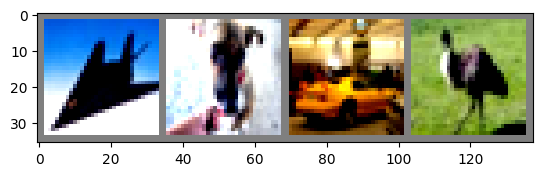

In [ ]:
##########################################################################
# A ``Dataset`` subclass wraps access to the data, and is specialized to
# the type of data it’s serving. The ``DataLoader`` knows *nothing* about
# the data, but organizes the input tensors served by the ``Dataset`` into
# batches with the parameters you specify.
#
# In the example above, we’ve asked a ``DataLoader`` to give us batches of
# 4 images from ``trainset``, randomizing their order (``shuffle=True``),
# and we told it to spin up two workers to load data from disk.
#
# It’s good practice to visualize the batches your ``DataLoader`` serves:
#

import matplotlib.pyplot as plt
import numpy as np

classes = ( 'dog', 'frog', 'horse', 'ship', 'truck','plane', 'car', 'bird', 'cat',
           'deer')

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))






 frog  deer horse  frog


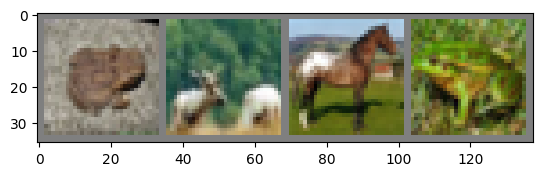

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
import torch.optim as optim

# import torchvision
# import torchvision.transforms as transforms

# import matplotlib
# import matplotlib.pyplot as plt
# import numpy as np


#########################################################################
# First, we’ll need training and test datasets. If you haven’t already,
# run the cell below to make sure the dataset is downloaded. (It may take
# a minute.)
#

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


######################################################################
# We’ll run our check on the output from ``DataLoader``:
#

import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))




In [ ]:


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()




criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)




In [ ]:


for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')




[1,  2000] loss: 2.150
[1,  4000] loss: 1.835
[1,  6000] loss: 1.645
[1,  8000] loss: 1.553
[1, 10000] loss: 1.529
[1, 12000] loss: 1.467
[2,  2000] loss: 1.409
[2,  4000] loss: 1.377
[2,  6000] loss: 1.369
[2,  8000] loss: 1.348
[2, 10000] loss: 1.308
[2, 12000] loss: 1.303
Finished Training


In [ ]:


correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))




Accuracy of the network on the 10000 test images: 54 %


# Tensors Deeper Tutorial


In [ ]:


import torch
import math


x = torch.empty(3, 4)
print(type(x))
print(x)




<class 'torch.Tensor'>
tensor([[ 5.5639e-15,  0.0000e+00,  1.1351e-43,  0.0000e+00],
        [ 5.4458e-15,  0.0000e+00,  9.1084e-44,  0.0000e+00],
        [ 4.4035e-15,  0.0000e+00, -4.1042e-21,  4.4533e-41]])


In [ ]:
zeros = torch.zeros(2, 3)
print(zeros)

ones = torch.ones(2, 3)
print(ones)

torch.manual_seed(1729)
random = torch.rand(2, 3)
print(random)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0.3126, 0.3791, 0.3087],
        [0.0736, 0.4216, 0.0691]])


In [ ]:
torch.manual_seed(1729)
random1 = torch.rand(2, 3)
print(random1)

random2 = torch.rand(2, 3)
print(random2)

torch.manual_seed(1729)
random3 = torch.rand(2, 3)
print(random3)

random4 = torch.rand(2, 3)
print(random4)

tensor([[0.3126, 0.3791, 0.3087],
        [0.0736, 0.4216, 0.0691]])
tensor([[0.2332, 0.4047, 0.2162],
        [0.9927, 0.4128, 0.5938]])
tensor([[0.3126, 0.3791, 0.3087],
        [0.0736, 0.4216, 0.0691]])
tensor([[0.2332, 0.4047, 0.2162],
        [0.9927, 0.4128, 0.5938]])


In [ ]:
x = torch.empty(2, 2, 3)
print(x.shape)
print(x)

torch.Size([2, 2, 3])
tensor([[[-4.1042e-21,  4.4533e-41,  5.4336e-14],
         [ 0.0000e+00,  4.4842e-44,  0.0000e+00]],

        [[ 1.1210e-43,  0.0000e+00,  4.3470e-15],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00]]])


In [ ]:
empty_like_x = torch.empty_like(x)
print(empty_like_x.shape)
print(empty_like_x)

torch.Size([2, 2, 3])
tensor([[[4.3463e-15, 0.0000e+00, 0.0000e+00],
         [1.5046e-36, 2.4007e-19, 0.0000e+00]],

        [[1.0842e-19, 0.0000e+00, 5.4308e-14],
         [0.0000e+00, 5.9854e-15, 0.0000e+00]]])


In [ ]:
zeros_like_x = torch.zeros_like(x)
print(zeros_like_x.shape)
print(zeros_like_x)

torch.Size([2, 2, 3])
tensor([[[0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.]]])


In [ ]:
ones_like_x = torch.ones_like(x)
print(ones_like_x.shape)
print(ones_like_x)

torch.Size([2, 2, 3])
tensor([[[1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.]]])


In [ ]:
rand_like_x = torch.rand_like(x)
print(rand_like_x.shape)
print(rand_like_x)

torch.Size([2, 2, 3])
tensor([[[0.2332, 0.4047, 0.2162],
         [0.9927, 0.4128, 0.5938]],

        [[0.6128, 0.1519, 0.0453],
         [0.5035, 0.9978, 0.3884]]])


In [ ]:
some_constants = torch.tensor([[3.1415926, 2.71828], [1.61803, 0.0072897]])
print(some_constants)

some_integers = torch.tensor((2, 3, 5, 7, 11, 13, 17, 19))
print(some_integers)

more_integers = torch.tensor(((2, 4, 6), [3, 6, 9]))
print(more_integers)

tensor([[3.1416, 2.7183],
        [1.6180, 0.0073]])
tensor([ 2,  3,  5,  7, 11, 13, 17, 19])
tensor([[2, 4, 6],
        [3, 6, 9]])


In [ ]:
a = torch.ones((2, 3), dtype=torch.int16)
print(a)

b = torch.rand((2, 3), dtype=torch.float64) * 20.
print(b)

c = b.to(torch.int32)
print(c)

tensor([[1, 1, 1],
        [1, 1, 1]], dtype=torch.int16)
tensor([[10.8626,  2.1505, 19.6913],
        [ 0.9956,  1.4148,  5.8364]], dtype=torch.float64)
tensor([[10,  2, 19],
        [ 0,  1,  5]], dtype=torch.int32)


In [ ]:
ones = torch.zeros(2, 2) + 1
twos = torch.ones(2, 2) * 2
threes = (torch.ones(2, 2) * 7 - 1) / 2
fours = twos ** 2
sqrt2s = twos ** 0.5

print(ones)
print(twos)
print(threes)
print(fours)
print(sqrt2s)

tensor([[1., 1.],
        [1., 1.]])
tensor([[2., 2.],
        [2., 2.]])
tensor([[3., 3.],
        [3., 3.]])
tensor([[4., 4.],
        [4., 4.]])
tensor([[1.4142, 1.4142],
        [1.4142, 1.4142]])


In [ ]:
powers2 = twos ** torch.tensor([[1, 2], [3, 4]])
print(powers2)

fives = ones + fours
print(fives)

dozens = threes * fours
print(dozens)

tensor([[ 2.,  4.],
        [ 8., 16.]])
tensor([[5., 5.],
        [5., 5.]])
tensor([[12., 12.],
        [12., 12.]])


In [ ]:


rand = torch.rand(2, 4)
doubled = rand * (torch.ones(1, 4) * 2)

print(rand)
print(doubled)

tensor([[0.0703, 0.5105, 0.9451, 0.2359],
        [0.1979, 0.3327, 0.6146, 0.5999]])
tensor([[0.1405, 1.0210, 1.8901, 0.4717],
        [0.3959, 0.6655, 1.2291, 1.1998]])


In [ ]:
a = torch.ones(4, 3, 2)

In [ ]:

b = a * torch.rand(   3, 2)
print(b)

tensor([[[0.5013, 0.9397],
         [0.8656, 0.5207],
         [0.6865, 0.3614]],

        [[0.5013, 0.9397],
         [0.8656, 0.5207],
         [0.6865, 0.3614]],

        [[0.5013, 0.9397],
         [0.8656, 0.5207],
         [0.6865, 0.3614]],

        [[0.5013, 0.9397],
         [0.8656, 0.5207],
         [0.6865, 0.3614]]])


In [ ]:
c = a * torch.rand(   3, 1)
print(c)

tensor([[[0.4762, 0.4762],
         [0.0548, 0.0548],
         [0.2024, 0.2024]],

        [[0.4762, 0.4762],
         [0.0548, 0.0548],
         [0.2024, 0.2024]],

        [[0.4762, 0.4762],
         [0.0548, 0.0548],
         [0.2024, 0.2024]],

        [[0.4762, 0.4762],
         [0.0548, 0.0548],
         [0.2024, 0.2024]]])


In [ ]:
d = a * torch.rand(   1, 2)
print(d)

tensor([[[0.6493, 0.2633],
         [0.6493, 0.2633],
         [0.6493, 0.2633]],

        [[0.6493, 0.2633],
         [0.6493, 0.2633],
         [0.6493, 0.2633]],

        [[0.6493, 0.2633],
         [0.6493, 0.2633],
         [0.6493, 0.2633]],

        [[0.6493, 0.2633],
         [0.6493, 0.2633],
         [0.6493, 0.2633]]])


In [ ]:
#common functions
a = torch.rand(2, 4) * 2 - 1
print('Common functions:')
print(torch.abs(a))
print(torch.ceil(a))
print(torch.floor(a))
print(torch.clamp(a, -0.5, 0.5))

Common functions:
tensor([[0.1461, 0.4382, 0.1866, 0.4602],
        [0.2551, 0.4715, 0.9238, 0.5724]])
tensor([[1., 1., -0., 1.],
        [1., 1., -0., -0.]])
tensor([[ 0.,  0., -1.,  0.],
        [ 0.,  0., -1., -1.]])
tensor([[ 0.1461,  0.4382, -0.1866,  0.4602],
        [ 0.2551,  0.4715, -0.5000, -0.5000]])


In [ ]:
#trigonometric functions and their inverses
angles = torch.tensor([0, math.pi / 5, math.pi / 6, 9 * math.pi / 4])
sines = torch.sin(angles)
inverses = torch.asin(sines)
print('\nSine and arcsine:')
print(angles)
print(sines)
print(inverses)


Sine and arcsine:
tensor([0.0000, 0.6283, 0.5236, 7.0686])
tensor([0.0000, 0.5878, 0.5000, 0.7071])
tensor([0.0000, 0.6283, 0.5236, 0.7854])


In [ ]:
#bitwise operations
print('\nBitwise XOR:')
b = torch.tensor([4, 5, 11])
c = torch.tensor([2, 8, 10])
print(torch.bitwise_xor(b, c))


Bitwise XOR:
tensor([ 6, 13,  1])


In [ ]:
# comparisons:
print('\nBroadcasted element-wise equality comparison:')
d = torch.tensor([[6., 4.], [3., 4.]])
e = torch.ones(1, 2)
print(torch.eq(d, e))


Broadcasted element-wise equality comparison:
tensor([[False, False],
        [False, False]])


In [ ]:

print('\nReduction ops:')
print(torch.max(d))
print(torch.max(d).item())
print(torch.mean(d))
print(torch.std(d))
print(torch.prod(d))
print(torch.unique(torch.tensor([3, 2, 1, 2, 1, 2])))


Reduction ops:
tensor(6.)
6.0
tensor(4.2500)
tensor(1.2583)
tensor(288.)
tensor([1, 2, 3])


In [ ]:

v1 = torch.tensor([6., 0., 0.])
v2 = torch.tensor([0., 5., 0.])
m1 = torch.rand(2, 2)
m2 = torch.tensor([[3., 0.], [0., 3.]])

In [ ]:
print('\nVectors & Matrices:')
print(torch.linalg.cross(v2, v1)) # negative of z unit vector (v1 x v2 == -v2 x v1)
print(m1)
m3 = torch.linalg.matmul(m1, m2)
print(m3)                  # 3 times m1
print(torch.linalg.svd(m3))       # singular value decomposition


Vectors & Matrices:
tensor([  0.,   0., -30.])
tensor([[0.5857, 0.6954],
        [0.0419, 0.0488]])
tensor([[1.7570, 2.0863],
        [0.1258, 0.1465]])
torch.return_types.linalg_svd(
U=tensor([[-0.9975, -0.0706],
        [-0.0706,  0.9975]]),
S=tensor([2.7344e+00, 1.9051e-03]),
Vh=tensor([[-0.6442, -0.7648],
        [ 0.7648, -0.6442]]))


In [ ]:


a = torch.tensor([0, math.pi / 4, math.pi / 2, 3 * math.pi / 4])
print('a:')
print(a)
print(torch.sin(a))   # this operation creates a new tensor in memory
print(a)              # a has not changed

a:
tensor([0.0000, 0.7854, 1.5708, 2.3562])
tensor([0.0000, 0.7071, 1.0000, 0.7071])
tensor([0.0000, 0.7854, 1.5708, 2.3562])


In [ ]:
b = torch.tensor([0, math.pi / 4, math.pi / 2, 3 * math.pi / 4])
print('\nb:')
print(b)
print(torch.sin_(b))  # note the underscore
print(b)              # b has changed


b:
tensor([0.0000, 0.7854, 1.5708, 2.3562])
tensor([0.0000, 0.7071, 1.0000, 0.7071])
tensor([0.0000, 0.7071, 1.0000, 0.7071])


In [ ]:

a = torch.ones(3, 2)
b = torch.rand(3, 2)

print('Before:')
print(a)
print(b)
print('\nAfter adding:')
print(a.add_(b))
print(a)
print(b)
print('\nAfter multiplying')
print(b.mul_(b))
print(b)

Before:
tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])
tensor([[0.7118, 0.5603],
        [0.8485, 0.5385],
        [0.8004, 0.7862]])

After adding:
tensor([[1.7118, 1.5603],
        [1.8485, 1.5385],
        [1.8004, 1.7862]])
tensor([[1.7118, 1.5603],
        [1.8485, 1.5385],
        [1.8004, 1.7862]])
tensor([[0.7118, 0.5603],
        [0.8485, 0.5385],
        [0.8004, 0.7862]])

After multiplying
tensor([[0.5066, 0.3139],
        [0.7200, 0.2900],
        [0.6407, 0.6181]])
tensor([[0.5066, 0.3139],
        [0.7200, 0.2900],
        [0.6407, 0.6181]])


In [ ]:



a = torch.rand(2, 2)
b = torch.rand(2, 2)
c = torch.zeros(2, 2)
old_id = id(c)

In [ ]:
print(c)
d = torch.matmul(a, b, out=c)
print(c)

assert c is d
assert id(c) == old_id

tensor([[0., 0.],
        [0., 0.]])
tensor([[0.7854, 0.9163],
        [0.4351, 0.4345]])


In [ ]:
torch.rand(2, 2, out=c) # works for creation too!
print(c)                # c has changed again
assert id(c) == old_id  # still the same object!

tensor([[0.0023, 0.4945],
        [0.3857, 0.9883]])


In [ ]:

#Copying Tensors

a = torch.ones(3, 3)
b = a

a[0][1] = 540
print(b)

tensor([[  1., 540.,   1.],
        [  1.,   1.,   1.],
        [  1.,   1.,   1.]])


In [ ]:


a = torch.ones(3, 2)
b = a.clone()

assert b is not a
print(torch.eq(a, b))

a[0][1] = 561
print(b)

tensor([[True, True],
        [True, True],
        [True, True]])
tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])


In [ ]:



a = torch.rand(2, 2, requires_grad=True) # turn on autograd
print(a)

b = a.clone()
print(b)

tensor([[0.8701, 0.5730],
        [0.8637, 0.6281]], requires_grad=True)
tensor([[0.8701, 0.5730],
        [0.8637, 0.6281]], grad_fn=<CloneBackward0>)


In [ ]:
c = a.detach().clone()
print(c)

print(a)

tensor([[0.4762, 0.7242],
        [0.0776, 0.4004]])
tensor([[0.4762, 0.7242],
        [0.0776, 0.4004]], requires_grad=True)


In [ ]:


if torch.accelerator.is_available():
    print('We have an accelerator!')
else:
    print('Sorry, CPU only.')

Sorry, CPU only.


In [ ]:

if torch.accelerator.is_available():
    gpu_rand = torch.rand(2, 2, device=torch.accelerator.current_accelerator())
    print(gpu_rand)
else:
    print('Sorry, CPU only.')

Sorry, CPU only.


In [ ]:


my_device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device('cpu')
print('Device: {}'.format(my_device))

Device: cpu


In [ ]:
x = torch.rand(2, 2, device=my_device)
print(x)








tensor([[0.9290, 0.6300],
        [0.3448, 0.0231]])


In [ ]:


y = torch.rand(3, 3)
y = y.to(my_device)


In [ ]:

#Manipulating Tensor Shapes


a = torch.rand(3, 226, 226)
b = a.unsqueeze(0)

print(a.shape)
print(b.shape)

torch.Size([3, 226, 226])
torch.Size([1, 3, 226, 226])


In [ ]:

c = torch.rand(1, 3, 1, 1, 2)
print(c)




tensor([[[[[0.9901, 0.8130]]],


         [[[0.0468, 0.4599]]],


         [[[0.4832, 0.9792]]]]])


In [ ]:


a = torch.rand(1, 10)
print(a.shape)
print(a)



torch.Size([1, 10])
tensor([[0.3057, 0.3161, 0.9517, 0.3112, 0.3124, 0.1298, 0.4751, 0.8744, 0.8591,
         0.3823]])


In [ ]:
b = a.squeeze(0)
print(b.shape)
print(b)



torch.Size([10])
tensor([0.3057, 0.3161, 0.9517, 0.3112, 0.3124, 0.1298, 0.4751, 0.8744, 0.8591,
        0.3823])


In [ ]:
c = torch.rand(2, 2)
print(c.shape)



torch.Size([2, 2])


In [ ]:
d = c.squeeze(0)
print(d.shape)

torch.Size([2, 2])


In [ ]:
a = torch.ones(4, 3, 2)
b = torch.rand(3)
c = b.unsqueeze(1)
print(c.shape)
print(a * c)



torch.Size([3, 1])
tensor([[[0.8677, 0.8677],
         [0.3530, 0.3530],
         [0.8987, 0.8987]],

        [[0.8677, 0.8677],
         [0.3530, 0.3530],
         [0.8987, 0.8987]],

        [[0.8677, 0.8677],
         [0.3530, 0.3530],
         [0.8987, 0.8987]],

        [[0.8677, 0.8677],
         [0.3530, 0.3530],
         [0.8987, 0.8987]]])


In [ ]:


batch_me = torch.rand(3, 226, 226)
print(batch_me.shape)
batch_me.unsqueeze_(0)
print(batch_me.shape)

torch.Size([3, 226, 226])
torch.Size([1, 3, 226, 226])


In [ ]:
output3d = torch.rand(5, 22, 22)
print(output3d.shape)

input1d = output3d.reshape(5 * 22 * 22)
print(input1d.shape)


print(torch.reshape(output3d, (5 * 22 * 22,)).shape)

torch.Size([5, 22, 22])
torch.Size([2420])
torch.Size([2420])


In [ ]:

import numpy as np

numpy_array = np.ones((2, 3))
print(numpy_array)

pytorch_tensor = torch.from_numpy(numpy_array)
print(pytorch_tensor)

[[1. 1. 1.]
 [1. 1. 1.]]
tensor([[1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)


In [ ]:


pytorch_rand = torch.rand(2, 3)
print(pytorch_rand)

numpy_rand = pytorch_rand.numpy()
print(numpy_rand)




numpy_array[1, 1] = 23
print(pytorch_tensor)

pytorch_rand[1, 1] = 17
print(numpy_rand)

tensor([[0.6839, 0.0662, 0.3758],
        [0.6230, 0.5277, 0.0844]])
[[0.68389285 0.06615222 0.37575275]
 [0.62295043 0.52773136 0.08439463]]
tensor([[ 1.,  1.,  1.],
        [ 1., 23.,  1.]], dtype=torch.float64)
[[ 0.68389285  0.06615222  0.37575275]
 [ 0.62295043 17.          0.08439463]]


# Autograd Tutorial



In [ ]:
#linespace

a = torch.linspace(0., 3. * math.pi, steps=40, requires_grad=True)
print(a)

tensor([0.0000, 0.2417, 0.4833, 0.7250, 0.9666, 1.2083, 1.4500, 1.6916, 1.9333,
        2.1749, 2.4166, 2.6583, 2.8999, 3.1416, 3.3833, 3.6249, 3.8666, 4.1082,
        4.3499, 4.5916, 4.8332, 5.0749, 5.3165, 5.5582, 5.7999, 6.0415, 6.2832,
        6.5248, 6.7665, 7.0082, 7.2498, 7.4915, 7.7332, 7.9748, 8.2165, 8.4581,
        8.6998, 8.9415, 9.1831, 9.4248], requires_grad=True)


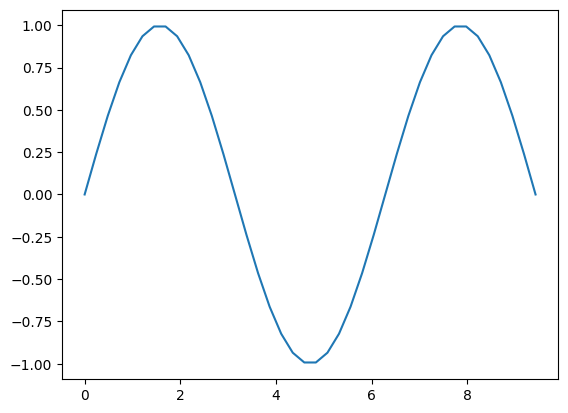

In [ ]:



b = torch.sin(a)
plt.plot(a.detach(), b.detach())




In [ ]:
#b history

print(b)


tensor([ 0.0000e+00,  2.3932e-01,  4.6472e-01,  6.6312e-01,  8.2298e-01,
         9.3502e-01,  9.9271e-01,  9.9271e-01,  9.3502e-01,  8.2298e-01,
         6.6312e-01,  4.6472e-01,  2.3932e-01,  1.5100e-07, -2.3932e-01,
        -4.6472e-01, -6.6312e-01, -8.2298e-01, -9.3502e-01, -9.9271e-01,
        -9.9271e-01, -9.3502e-01, -8.2298e-01, -6.6312e-01, -4.6472e-01,
        -2.3932e-01,  1.7485e-07,  2.3932e-01,  4.6472e-01,  6.6312e-01,
         8.2298e-01,  9.3502e-01,  9.9271e-01,  9.9271e-01,  9.3502e-01,
         8.2298e-01,  6.6312e-01,  4.6472e-01,  2.3932e-01, -2.3850e-08],
       grad_fn=<SinBackward0>)


In [ ]:

# more computations


c = 2 * b
print(c)

tensor([ 0.0000e+00,  4.7863e-01,  9.2945e-01,  1.3262e+00,  1.6460e+00,
         1.8700e+00,  1.9854e+00,  1.9854e+00,  1.8700e+00,  1.6460e+00,
         1.3262e+00,  9.2945e-01,  4.7863e-01,  3.0199e-07, -4.7863e-01,
        -9.2945e-01, -1.3262e+00, -1.6460e+00, -1.8700e+00, -1.9854e+00,
        -1.9854e+00, -1.8700e+00, -1.6460e+00, -1.3262e+00, -9.2945e-01,
        -4.7863e-01,  3.4969e-07,  4.7863e-01,  9.2945e-01,  1.3262e+00,
         1.6460e+00,  1.8700e+00,  1.9854e+00,  1.9854e+00,  1.8700e+00,
         1.6460e+00,  1.3262e+00,  9.2945e-01,  4.7863e-01, -4.7700e-08],
       grad_fn=<MulBackward0>)


In [ ]:
d = c + 1
print(d)

tensor([ 1.0000,  1.4786,  1.9294,  2.3262,  2.6460,  2.8700,  2.9854,  2.9854,
         2.8700,  2.6460,  2.3262,  1.9294,  1.4786,  1.0000,  0.5214,  0.0706,
        -0.3262, -0.6460, -0.8700, -0.9854, -0.9854, -0.8700, -0.6460, -0.3262,
         0.0706,  0.5214,  1.0000,  1.4786,  1.9294,  2.3262,  2.6460,  2.8700,
         2.9854,  2.9854,  2.8700,  2.6460,  2.3262,  1.9294,  1.4786,  1.0000],
       grad_fn=<AddBackward0>)


In [ ]:

# loss function.


out = d.sum()
print(out)

tensor(56.4715, grad_fn=<SumBackward0>)


In [ ]:

print('d:')
print(d.grad_fn)
print(d.grad_fn.next_functions)
print(d.grad_fn.next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions[0][0].next_functions)

d:
((<MulBackward0 object at 0x7c22efa97be0>, 0), (None, 0))
((<SinBackward0 object at 0x7c22efa97be0>, 0), (None, 0))
((<AccumulateGrad object at 0x7c22efa972b0>, 0),)
()


In [ ]:
print('\nc:')
print(c.grad_fn)
print('\nb:')
print(b.grad_fn)
print('\na:')
print(a.grad_fn)


c:

b:

a:
None


tensor([ 2.0000,  1.9419,  1.7709,  1.4970,  1.1361,  0.7092,  0.2411, -0.2411,
        -0.7092, -1.1361, -1.4970, -1.7709, -1.9419, -2.0000, -1.9419, -1.7709,
        -1.4970, -1.1361, -0.7092, -0.2411,  0.2411,  0.7092,  1.1361,  1.4970,
         1.7709,  1.9419,  2.0000,  1.9419,  1.7709,  1.4970,  1.1361,  0.7092,
         0.2411, -0.2411, -0.7092, -1.1361, -1.4970, -1.7709, -1.9419, -2.0000])


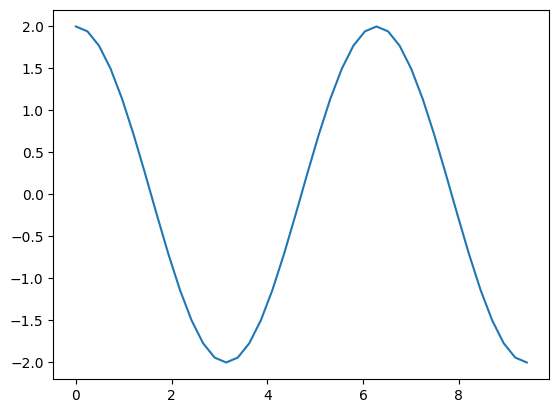

In [ ]:


out.backward()
print(a.grad)
plt.plot(a.detach(), a.grad.detach())

In [ ]:

# Autograd in Training


BATCH_SIZE = 20
DIM_IN = 800
HIDDEN_SIZE = 80
DIM_OUT = 10

class TinyModel(torch.nn.Module):

    def __init__(self):
        super(TinyModel, self).__init__()

        self.layer1 = torch.nn.Linear(DIM_IN, HIDDEN_SIZE)
        self.relu = torch.nn.ReLU()
        self.layer2 = torch.nn.Linear(HIDDEN_SIZE, DIM_OUT)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

some_input = torch.randn(BATCH_SIZE, DIM_IN, requires_grad=False)
ideal_output = torch.randn(BATCH_SIZE, DIM_OUT, requires_grad=False)

model = TinyModel()




print(model.layer2.weight[0][0:10]) # just a small slice
print(model.layer2.weight.grad)




tensor([ 0.0752,  0.1048, -0.0030,  0.0337,  0.1090,  0.0153, -0.1116, -0.0889,
        -0.0550,  0.0438], grad_fn=<SliceBackward0>)
None


In [ ]:
#stochastic gradient descent.


optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

prediction = model(some_input)

loss = (ideal_output - prediction).pow(2).sum()
print(loss)




tensor(223.0451, grad_fn=<SumBackward0>)


In [ ]:

#loss.backward()


loss.backward()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])




tensor([ 0.0752,  0.1048, -0.0030,  0.0337,  0.1090,  0.0153, -0.1116, -0.0889,
        -0.0550,  0.0438], grad_fn=<SliceBackward0>)
tensor([ 4.6564,  3.2504,  4.9641,  7.3398,  3.2703,  5.4777, -2.5307, -0.3446,
        -2.2387,  0.2526])


In [ ]:
#optimer step

optimizer.step()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])




tensor([ 0.0706,  0.1015, -0.0079,  0.0264,  0.1057,  0.0098, -0.1091, -0.0886,
        -0.0528,  0.0435], grad_fn=<SliceBackward0>)
tensor([ 4.6564,  3.2504,  4.9641,  7.3398,  3.2703,  5.4777, -2.5307, -0.3446,
        -2.2387,  0.2526])


In [ ]:

# layer 2 weight change

print(model.layer2.weight.grad[0][0:10])

for i in range(0, 5):
    prediction = model(some_input)
    loss = (ideal_output - prediction).pow(2).sum()
    loss.backward()

print(model.layer2.weight.grad[0][0:10])

optimizer.zero_grad(set_to_none=False)

print(model.layer2.weight.grad[0][0:10])




tensor([ 4.6564,  3.2504,  4.9641,  7.3398,  3.2703,  5.4777, -2.5307, -0.3446,
        -2.2387,  0.2526])
tensor([21.1659, 14.0630, 25.9877, 29.3010, -3.6085, 22.5175, -6.9573, -3.8056,
        -8.3749,  2.7469])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [ ]:
a = torch.ones(3, 3, requires_grad=True)
print(a)

b1 = 2 * a
print(b1)

a.requires_grad = False
b2 = 2 * a
print(b2)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)
tensor([[2., 2., 2.],
        [2., 2., 2.],
        [2., 2., 2.]], grad_fn=<MulBackward0>)
tensor([[2., 2., 2.],
        [2., 2., 2.],
        [2., 2., 2.]])


In [ ]:
a = torch.ones(3, 3, requires_grad=True) * 2
b = torch.ones(3, 3, requires_grad=True) * 3

c1 = a + b
print(c1)

with torch.no_grad():
    c2 = a + b

print(c2)

c3 = a * b
print(c3)

tensor([[5., 5., 5.],
        [5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.],
        [5., 5., 5.]])
tensor([[6., 6., 6.],
        [6., 6., 6.],
        [6., 6., 6.]], grad_fn=<MulBackward0>)


In [ ]:

#torch.no_grad() used as a function decorator:


def add_tensors1(x, y):
    return x + y

@torch.no_grad()
def add_tensors2(x, y):
    return x + y

In [ ]:
a = torch.ones(2, 3, requires_grad=True) * 2
b = torch.ones(2, 3, requires_grad=True) * 3

c1 = add_tensors1(a, b)
print(c1)

c2 = add_tensors2(a, b)
print(c2)

tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.]])


In [ ]:
#random

x = torch.rand(5, requires_grad=True)
y = x.detach()

print(x)
print(y)

tensor([0.2046, 0.4537, 0.0876, 0.7506, 0.3751], requires_grad=True)
tensor([0.2046, 0.4537, 0.0876, 0.7506, 0.3751])


In [ ]:
#Autograd Profiler


device = torch.device('cpu')
run_on_gpu = False
if torch.cuda.is_available():
    device = torch.device('cuda')
    run_on_gpu = True

x = torch.randn(2, 3, requires_grad=True)
y = torch.rand(2, 3, requires_grad=True)
z = torch.ones(2, 3, requires_grad=True)

In [ ]:
with torch.autograd.profiler.profile(use_cuda=run_on_gpu) as prf:
    for _ in range(1000):
        z = (z / x) * y

print(prf.key_averages().table(sort_by='self_cpu_time_total'))

-------------  ------------  ------------  ------------  ------------  ------------  ------------  
         Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-------------  ------------  ------------  ------------  ------------  ------------  ------------  
    aten::mul        50.06%       2.098ms        50.06%       2.098ms       2.098us          1000  
    aten::div        49.94%       2.093ms        49.94%       2.093ms       2.093us          1000  
-------------  ------------  ------------  ------------  ------------  ------------  ------------  
Self CPU time total: 4.190ms



In [ ]:


x = torch.randn(3, requires_grad=True)

y = x * 2
while y.data.norm() < 1000:
    y = y * 2

print(y)

tensor([ -129.6953,  -478.6207, -1378.1908], grad_fn=<MulBackward0>)


In [ ]:


v = torch.tensor([0.1, 1.0, 0.0001], dtype=torch.float) #gradients stand in
y.backward(v)

print(x.grad)

tensor([1.0240e+02, 1.0240e+03, 1.0240e-01])


In [ ]:

def exp_adder(x, y):
    return 2 * x.exp() + 3 * y

inputs = (torch.rand(1), torch.rand(1))
print(inputs)
torch.autograd.functional.jacobian(exp_adder, inputs)

(tensor([0.0379]), tensor([0.9119]))


(tensor([[2.0774]]), tensor([[3.]]))

In [ ]:


inputs = (torch.rand(3), torch.rand(3))
print(inputs)
torch.autograd.functional.jacobian(exp_adder, inputs)

(tensor([0.0688, 0.2298, 0.5582]), tensor([0.3511, 0.9650, 0.7731]))


(tensor([[2.1425, 0.0000, 0.0000],
         [0.0000, 2.5166, 0.0000],
         [0.0000, 0.0000, 3.4952]]),
 tensor([[3., 0., 0.],
         [0., 3., 0.],
         [0., 0., 3.]]))

In [ ]:


def do_some_doubling(x):
    y = x * 2
    while y.data.norm() < 1000:
        y = y * 2
    return y

inputs = torch.randn(3)
my_gradients = torch.tensor([0.1, 1.0, 0.0001])
torch.autograd.functional.vjp(do_some_doubling, inputs, v=my_gradients)

(tensor([-460.6039, 1006.1436, -510.3170]),
 tensor([5.1200e+01, 5.1200e+02, 5.1200e-02]))

# Models Tutorial


In [ ]:




class TinyModel(torch.nn.Module):

    def __init__(self):
        super(TinyModel, self).__init__()

        self.linear1 = torch.nn.Linear(100, 200)
        self.activation = torch.nn.ReLU()
        self.linear2 = torch.nn.Linear(200, 10)
        self.softmax = torch.nn.Softmax()

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.softmax(x)
        return x














In [ ]:
tinymodel = TinyModel()


print(tinymodel)







TinyModel(
  (linear1): Linear(in_features=100, out_features=200, bias=True)
  (activation): ReLU()
  (linear2): Linear(in_features=200, out_features=10, bias=True)
  (softmax): Softmax(dim=None)
)


In [ ]:
print('one layer:')
print(tinymodel.linear2)

one layer:
Linear(in_features=200, out_features=10, bias=True)


In [ ]:
print('Model param:')
for param in tinymodel.parameters():
    print(param)

Model param:
Parameter containing:
tensor([[-0.0703,  0.0781,  0.0838,  ..., -0.0624, -0.0957,  0.0030],
        [-0.0463,  0.0128,  0.0096,  ..., -0.0150, -0.0662,  0.0014],
        [-0.0778,  0.0587,  0.0143,  ..., -0.0874,  0.0436, -0.0111],
        ...,
        [ 0.0832, -0.0961, -0.0212,  ...,  0.0681, -0.0284,  0.0836],
        [ 0.0313, -0.0067, -0.0051,  ..., -0.0321,  0.0749, -0.0500],
        [-0.0660,  0.0199, -0.0726,  ..., -0.0104, -0.0201, -0.0197]],
       requires_grad=True)
Parameter containing:
tensor([-0.0964,  0.0418, -0.0374, -0.0131, -0.0809,  0.0611,  0.0900,  0.0466,
         0.0777,  0.0782,  0.0564, -0.0328, -0.0373, -0.0438,  0.0710, -0.0257,
         0.0873,  0.0802, -0.0465,  0.0052, -0.0879, -0.0631, -0.0570,  0.0889,
         0.0426, -0.0474, -0.0093, -0.0027,  0.0864,  0.0100, -0.0022,  0.0738,
        -0.0122, -0.0197, -0.0878, -0.0581, -0.0680, -0.0438, -0.0949,  0.0055,
         0.0021,  0.0067, -0.0679, -0.0989,  0.0586, -0.0902, -0.0864, -0.0440,
  

In [ ]:
print('layer param:')
for param in tinymodel.linear2.parameters():
    print(param)

layer param:
Parameter containing:
tensor([[-0.0188,  0.0525,  0.0240,  ..., -0.0543,  0.0560,  0.0351],
        [-0.0370,  0.0074, -0.0118,  ...,  0.0024,  0.0044,  0.0355],
        [ 0.0185, -0.0147,  0.0071,  ...,  0.0564, -0.0215,  0.0438],
        ...,
        [-0.0362,  0.0221,  0.0087,  ...,  0.0073,  0.0387,  0.0270],
        [-0.0254,  0.0049,  0.0428,  ..., -0.0212,  0.0055,  0.0345],
        [-0.0401, -0.0139,  0.0422,  ...,  0.0458, -0.0004,  0.0337]],
       requires_grad=True)
Parameter containing:
tensor([-0.0452, -0.0506,  0.0378, -0.0379,  0.0363,  0.0167,  0.0400,  0.0624,
        -0.0441, -0.0081], requires_grad=True)


In [ ]:

#Linear Layers


lin = torch.nn.Linear(3, 3)
x = torch.rand(1, 3)
print('Input:')
print(x)

print('Weight and Bias:')
for param in lin.parameters():
    print(param)

y = lin(x)
print('Output:')
print(y)

Input:
tensor([[0.8273, 0.2283, 0.8544]])
Weight and Bias:
Parameter containing:
tensor([[ 0.5571, -0.4915, -0.1518],
        [ 0.5594, -0.2237, -0.2430],
        [ 0.2885,  0.5455, -0.2295]], requires_grad=True)
Parameter containing:
tensor([-0.3355, -0.0382,  0.2906], requires_grad=True)
Output:
tensor([[-0.1165,  0.1659,  0.4578]], grad_fn=<AddmmBackward0>)


In [ ]:
# Convolutional Layers - Lnet





class LeNet(torch.nn.Module):

    def __init__(self):
        super(LeNet, self).__init__()

        self.conv1 = torch.nn.Conv2d(1, 6, 5)
        self.conv2 = torch.nn.Conv2d(6, 16, 3)

        self.fc1 = torch.nn.Linear(16 * 6 * 6, 120)  #image dimension
        self.fc2 = torch.nn.Linear(120, 84)
        self.fc3 = torch.nn.Linear(84, 10)

    def forward(self, x):

        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))

        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]
        num_features = 1
        for s in size:
            num_features *= s
        return num_features


In [ ]:
class LSTMTagger(torch.nn.Module):

    def __init__(self, embedding_dim, hidden_dim, vocab_size, tagset_size):
        super(LSTMTagger, self).__init__()
        self.hidden_dim = hidden_dim

        self.word_embeddings = torch.nn.Embedding(vocab_size, embedding_dim)


        self.lstm = torch.nn.LSTM(embedding_dim, hidden_dim)


        self.hidden2tag = torch.nn.Linear(hidden_dim, tagset_size)

    def forward(self, sentence):
        embeds = self.word_embeddings(sentence)
        lstm_out, _ = self.lstm(embeds.view(len(sentence), 1, -1))
        tag_space = self.hidden2tag(lstm_out.view(len(sentence), -1))
        tag_scores = F.log_softmax(tag_space, dim=1)
        return tag_scores










In [ ]:

# Max pooling


my_tensor = torch.rand(1, 6, 6)
print(my_tensor)

maxpool_layer = torch.nn.MaxPool2d(3)
print(maxpool_layer(my_tensor))

tensor([[[0.8528, 0.0303, 0.7816, 0.5211, 0.3902, 0.0934],
         [0.8512, 0.1629, 0.7172, 0.0836, 0.2496, 0.9446],
         [0.6554, 0.1391, 0.0823, 0.1124, 0.8520, 0.0199],
         [0.4801, 0.1244, 0.8088, 0.9529, 0.4982, 0.3931],
         [0.8216, 0.9960, 0.4621, 0.1205, 0.0533, 0.7890],
         [0.2844, 0.4265, 0.8174, 0.4747, 0.7463, 0.4882]]])
tensor([[[0.8528, 0.9446],
         [0.9960, 0.9529]]])


In [ ]:

#Normalization layers and output to one layer


my_tensor = torch.rand(1, 4, 4) * 20 + 5
print(my_tensor)

print(my_tensor.mean())

tensor([[[ 6.1849, 22.4102,  9.7949, 18.0181],
         [20.0106, 20.3134, 15.6877,  7.3940],
         [ 6.1725,  7.1725, 15.2768, 10.5301],
         [ 9.9196, 17.8933, 12.6572,  9.9589]]])
tensor(13.0872)


In [ ]:
norm_layer = torch.nn.BatchNorm1d(4)
normed_tensor = norm_layer(my_tensor)
print(normed_tensor)

print(normed_tensor.mean())





tensor([[[-0.6640,  1.7249, -0.6334, -0.4275],
         [ 0.1298, -1.1586,  1.5419, -0.5131],
         [-1.0983, -0.7265,  0.3642,  1.4606],
         [ 1.6969, -0.8311, -0.2670, -0.5987]]],
       grad_fn=<NativeBatchNormBackward0>)
tensor(6.7055e-08, grad_fn=<MeanBackward0>)


In [ ]:
#Dropout layers


my_tensor = torch.rand(1, 4, 4)

dropout = torch.nn.Dropout(p=0.4)
print(dropout(my_tensor))
print(dropout(my_tensor))




tensor([[[0.9235, 0.0000, 0.5635, 0.0000],
         [1.2725, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0658, 0.6231, 0.1151],
         [0.0000, 0.5652, 0.7918, 0.8265]]])
tensor([[[0.9235, 0.0000, 0.5635, 1.3385],
         [0.0000, 0.2857, 0.0000, 1.5148],
         [0.9059, 0.0658, 0.0000, 0.0000],
         [0.6035, 0.0000, 0.0000, 0.8265]]])


# TensorBoard Tutorial


In [ ]:





# PyTorch TensorBoard support
from torch.utils.tensorboard import SummaryWriter


transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])


























In [ ]:
# Store separate training and validations splits in ./data
training_set = torchvision.datasets.FashionMNIST('./data',
    download=True,
    train=True,
    transform=transform)
validation_set = torchvision.datasets.FashionMNIST('./data',
    download=True,
    train=False,
    transform=transform)

training_loader = torch.utils.data.DataLoader(training_set,
                                              batch_size=4,
                                              shuffle=True,
                                              num_workers=2)


validation_loader = torch.utils.data.DataLoader(validation_set,
                                                batch_size=4,
                                                shuffle=False,
                                                num_workers=2)

In [ ]:
# Class labels
classes = ('Sneaker', 'Bag', 'Ankle Boot','T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt')


def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.6
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

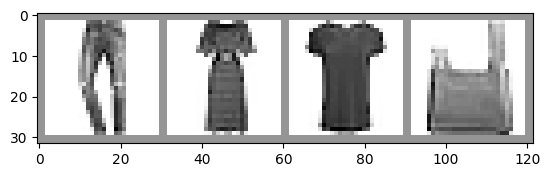

In [ ]:
#batch of 4 image extraction
dataiter = iter(training_loader)
images, labels = next(dataiter)

#create grid image
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)



writer = SummaryWriter('runs/fashion_mnist_experiment_1')


writer.add_image('Four Fashion-MNIST Images', img_grid)
writer.flush()


In [ ]:

#loss function training:

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [ ]:

#setting loss after every 1000 batch

print(len(validation_loader))
for epoch in range(1):
    running_loss = 0.0

    for i, data in enumerate(training_loader, 0):
        #training loop
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 1000 == 999:    #Every 1000 batch
            print('Batch {}'.format(i + 1))
            #Check against the validation set
            running_vloss = 0.0

            #omit dropout layer for eval
            net.train(False) #
            for j, vdata in enumerate(validation_loader, 0):
                vinputs, vlabels = vdata
                voutputs = net(vinputs)
                vloss = criterion(voutputs, vlabels)
                running_vloss += vloss.item()
            net.train(True) #back to training mode

            avg_loss = running_loss / 1000
            avg_vloss = running_vloss / len(validation_loader)

            #Log the running loss averaged per batch
            writer.add_scalars('Training vs. Validation Loss',
                            { 'Training' : avg_loss, 'Validation' : avg_vloss },
                            epoch * len(training_loader) + i)

            running_loss = 0.0
print('Finished Training')

writer.flush()

2500
Batch 1000
Batch 2000
Batch 3000
Batch 4000
Batch 5000
Batch 6000
Batch 7000
Batch 8000
Batch 9000
Batch 10000
Batch 11000
Batch 12000
Batch 13000
Batch 14000
Batch 15000
Finished Training


In [ ]:
#getting single batch of image
dataiter = iter(training_loader)
images, labels = next(dataiter)

#add_graph() to trace the sample input through model,

writer.add_graph(net, images)
writer.flush()

In [ ]:
#random data
def select_n_random(data, labels, n=100):
    assert len(data) == len(labels)

    perm = torch.randperm(len(data))
    return data[perm][:n], labels[perm][:n]

In [ ]:

images, labels = select_n_random(training_set.data, training_set.targets)


class_labels = [classes[label] for label in labels]

#log embeddings
features = images.view(-1, 28 * 28)
writer.add_embedding(features,
                    metadata=class_labels,
                    label_img=images.unsqueeze(1))
writer.flush()
writer.close()

# Training Tutorial


In [ ]:

#Dataset and DataLoader



from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)


training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False)

classes = ('Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot','T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat')

print('Training set has {} instances'.format(len(training_set)))
print('Validation set has {} instances'.format(len(validation_set)))























Training set has 60000 instances
Validation set has 10000 instances


T-shirt/top  T-shirt/top  Sneaker  Shirt


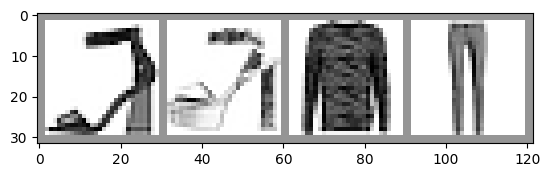

In [ ]:


def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.6     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

In [ ]:


class GarmentClassifier(nn.Module):
    def __init__(self):
        super(GarmentClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x






In [ ]:
model = GarmentClassifier()




loss_fn = torch.nn.CrossEntropyLoss()

dummy_outputs = torch.rand(4, 10)

dummy_labels = torch.tensor([1, 5, 3, 7])

print(dummy_outputs)
print(dummy_labels)

tensor([[0.2257, 0.1892, 0.4153, 0.3097, 0.5327, 0.2068, 0.6052, 0.3897, 0.7522,
         0.6728],
        [0.5944, 0.0713, 0.9485, 0.2690, 0.1349, 0.4325, 0.4396, 0.8471, 0.3853,
         0.9074],
        [0.3001, 0.9971, 0.5920, 0.3869, 0.0739, 0.5940, 0.8868, 0.5867, 0.7465,
         0.8114],
        [0.9034, 0.0300, 0.9982, 0.1809, 0.0800, 0.4201, 0.0033, 0.1600, 0.9932,
         0.7615]])
tensor([1, 5, 3, 7])


In [ ]:
loss = loss_fn(dummy_outputs, dummy_labels)
print('Total loss for this batch: {}'.format(loss.item()))

Total loss for this batch: 2.550705909729004


In [ ]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.


    for i, data in enumerate(training_loader):

        inputs, labels = data

        #zero every batch
        optimizer.zero_grad()

        #predict for this batch
        outputs = model(inputs)

        #calculate the loss and its gradient
        loss = loss_fn(outputs, labels)
        loss.backward()

        #learning weights
        optimizer.step()

        #get data and loss
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss

In [ ]:

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

EPOCHS = 4

best_vloss = 1_000_00.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))


    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)


    running_vloss = 0.0

    # statistics
    model.eval()

    #Disable gradient computation(reduce memory consumption)
    with torch.no_grad():
        for i, vdata in enumerate(validation_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))


    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
    writer.flush()


    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)

    epoch_number += 1

EPOCH 1:
  batch 1000 loss: 2.3041509492397307
  batch 2000 loss: 2.3037612302303314
  batch 3000 loss: 2.3029317710399626
  batch 4000 loss: 2.30406712269783
  batch 5000 loss: 2.3050171172618867
  batch 6000 loss: 2.3046739411354067
  batch 7000 loss: 2.304425366640091
  batch 8000 loss: 2.3047217292785644
  batch 9000 loss: 2.30494776058197
  batch 10000 loss: 2.303745919704437
  batch 11000 loss: 2.3044414331912995
  batch 12000 loss: 2.303838501691818
  batch 13000 loss: 2.305711887359619
  batch 14000 loss: 2.3047604830265045
  batch 15000 loss: 2.3035732769966124
LOSS train 2.3035732769966124 valid 2.3043510913848877
EPOCH 2:
  batch 1000 loss: 2.305294596672058
  batch 2000 loss: 2.30422137761116
  batch 3000 loss: 2.3042656190395356
  batch 4000 loss: 2.303007076501846
  batch 5000 loss: 2.303322697162628
  batch 6000 loss: 2.3061852662563322
  batch 7000 loss: 2.3042526919841766
  batch 8000 loss: 2.3059974479675294
  batch 9000 loss: 2.303456026315689
  batch 10000 loss: 2.3

# Captum Tutorial


In [ ]:
!pip install captum

In [ ]:

#Model Understanding with Captum


import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models

import captum
from captum.attr import IntegratedGradients, Occlusion, LayerGradCam, LayerAttribution
from captum.attr import visualization as viz
from io import BytesIO
import os, sys
import json
import requests
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap




In [ ]:

#Using ResNet



# model = models.resnet18(weights='IMAGENET1K_V1')
# model = model.eval()




In [ ]:
#importing image from github
# from io import BytesIO
# import requests
# url = "https://raw.githubusercontent.com/pytorch/tutorials/main/_static/img/cat.jpg"
# response = requests.get(url)
# test_img = Image.open(BytesIO(response.content))
# test_img_data = np.asarray(test_img)

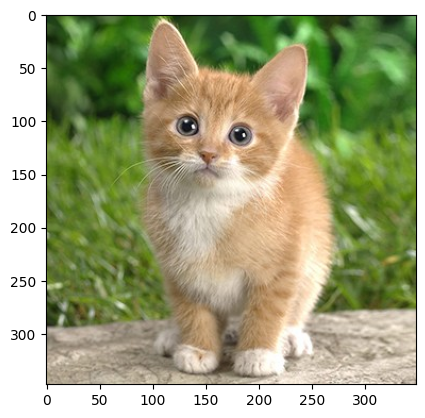

In [ ]:


# test_img = Image.open('cat.jpg')
# test_img_data = np.asarray(test_img)
# plt.imshow(test_img_data)
# plt.show()

In [ ]:

#3-color image
# transform = transforms.Compose([
#  transforms.Resize(224),
#  transforms.CenterCrop(224),
#  transforms.ToTensor()
# ])

In [ ]:
#normalization
# transform_normalize = transforms.Normalize(
#      mean=[0.485, 0.456, 0.406],
#      std=[0.229, 0.224, 0.225]
#  )

# transformed_img = transform(test_img)
# input_img = transform_normalize(transformed_img)
# input_img = input_img.unsqueeze(0)



In [ ]:
#let's import labels from github too
# labels_url = "https://raw.githubusercontent.com/pytorch/tutorials/main/_static/imagenet_class_index.json"
# response = requests.get(labels_url)
# imagenet_labels = json.loads(response.content)

In [ ]:

# labels_path = 'img/imagenet_class_index.json'
# with open(labels_path) as json_data:
#     idx_to_labels = json.load(json_data)

# idx_to_labels = json.loads(response.content)

In [ ]:

# output = model(input_img)
# output = F.softmax(output, dim=1)
# prediction_score, pred_label_idx = torch.topk(output, 1)
# pred_label_idx.squeeze_()
# predicted_label = idx_to_labels[str(pred_label_idx.item())][1]
# print('Predicted:', predicted_label, '(', prediction_score.squeeze().item(), ')')

Predicted: tabby ( 0.4803225100040436 )


In [ ]:

# integrated_gradients = IntegratedGradients(model)


# attributions_ig = integrated_gradients.attribute(input_img, target=pred_label_idx, n_steps=200)



=====================================================================


In [ ]:


model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#load and process image
def load_and_preprocess_image(url):
    img = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ])
    transform_normalize = transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
    t_img = transform(img)
    input_img = transform_normalize(t_img).unsqueeze(0)  # add batch
    return img, t_img, input_img

In [ ]:
#images
img_urls = [
    "https://raw.githubusercontent.com/pytorch/tutorials/main/_static/img/cat.jpg",
    "https://raw.githubusercontent.com/pytorch/tutorials/main/_static/img/teapot.jpg",
    "https://raw.githubusercontent.com/pytorch/tutorials/main/_static/img/trilobite.jpg"
]

In [ ]:
#get label
labels_url = "https://raw.githubusercontent.com/pytorch/tutorials/main/_static/imagenet_class_index.json"
idx_to_labels = json.loads(requests.get(labels_url).content)

In [ ]:
# Pick one image for Integrated Gradients
# ------------------------------
orig_img, transformed_img, input_img = load_and_preprocess_image(img_urls[0])

In [ ]:
# Forward pass
output = model(input_img)
output = F.softmax(output, dim=1)
pred_score, pred_idx = torch.topk(output, 1)
pred_idx = pred_idx.squeeze()
pred_label = idx_to_labels[str(pred_idx.item())][1]
print("Predicted:", pred_label, "Score:", pred_score.item())

Predicted: tabby Score: 0.4803225100040436


In [ ]:
img_np = np.transpose(transformed_img.cpu().detach().numpy(), (1, 2, 0))

In [ ]:

#integrated gradient
ig = IntegratedGradients(model)
attr_ig = ig.attribute(input_img, target=pred_idx, n_steps=200)




In [ ]:
print(transformed_img.shape)

torch.Size([3, 224, 224])


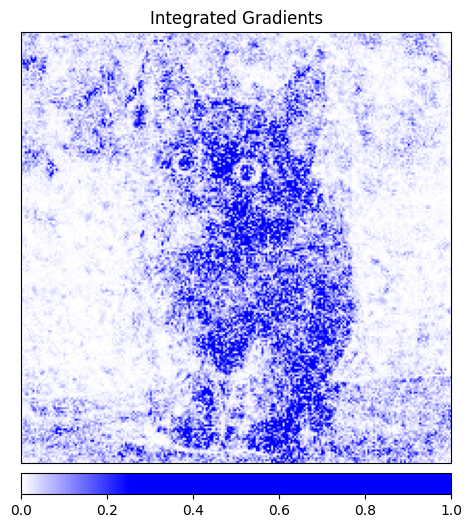

In [ ]:
# Visualize attribution heatmap
attr_np = np.transpose(attr_ig.squeeze().detach().numpy(), (1,2,0))
default_cmap = LinearSegmentedColormap.from_list('custom blue', [(0,'#ffffff'),(0.25,'#0000ff'),(1,'#0000ff')], N=256)
_ = viz.visualize_image_attr(attr_np, img_np, method="heat_map", cmap=default_cmap, show_colorbar=True, title="Integrated Gradients")


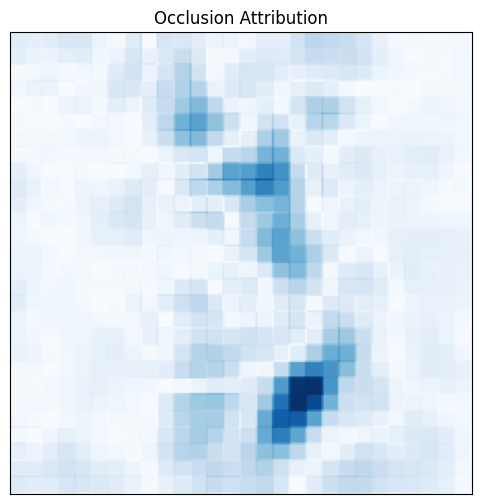

In [ ]:

#Occlusion example

occlusion = Occlusion(model)
attr_occ = occlusion.attribute(input_img, target=pred_idx,
                               strides=(3,8,8),
                               sliding_window_shapes=(3,15,15),
                               baselines=0)
attr_occ_np = np.transpose(attr_occ.squeeze().detach().numpy(), (1,2,0))
_ = viz.visualize_image_attr(attr_occ_np, img_np, method="heat_map", title="Occlusion Attribution")
